# 04 - Analyse de l'incertitude et calibration

J'analyse l'explicabilité du BNN image only sous deux angles : l'incertitude épistémique par classe (le modèle sait-il quand il est incertain ?) et la calibration mesurée par l'ECE. Je compare au CNN baseline et au BNN multimodal.

### 1. Imports et seed

In [28]:
import os, random, glob
import numpy as np
import torch
import torch.nn as nn
import torchbnn as bnn
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: mps


### 2. Chemins et config

In [29]:
DATAROOT    = "/Users/teodul/Documents/Memoire/Brain Tumor MRI clean"
TEST_DIR    = os.path.join(DATAROOT, "Test")
BNN_CKPT    = "runs_bnn_multimodal/ablation_image_only.pt"
SAVE_DIR    = "runs_analysis"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE    = 224
MC_PASSES   = 50
CLASSES     = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = 4
COLORS      = ["tomato", "steelblue", "seagreen", "darkorange"]

### 3. Recharge du modèle BNN

In [30]:
class BNNImageOnly(nn.Module):
    def __init__(self, num_classes=4, prior_mu=0, prior_sigma=0.1):
        super().__init__()
        backbone = models.resnet18(weights="IMAGENET1K_V1")
        backbone.fc = nn.Identity()
        self.cnn = backbone
        for param in self.cnn.parameters():
            param.requires_grad = False
        self.bnn_head = nn.Sequential(
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=512, out_features=256),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=256, out_features=128),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=128, out_features=num_classes),
        )
    def forward(self, img, clinical=None):
        return self.bnn_head(self.cnn(img))


model = BNNImageOnly().to(device)
ckpt  = torch.load(BNN_CKPT, map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state"])
print(f"✓ Modèle chargé (epoch {ckpt['epoch']}, AUC={ckpt['auc']:.3f})")

✓ Modèle chargé (epoch 15, AUC=0.993)


### 4. Transforms et utilitaires

In [31]:
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    return val_tf(img).unsqueeze(0).to(device)

def predict_bnn(img_tensor, clinical_array, n_passes=MC_PASSES):
    model.eval()
    results_mean, results_std = [], []

    with torch.no_grad():
        for clin in clinical_array:
            clin_t = torch.tensor(clin, dtype=torch.float32).unsqueeze(0).to(device)
            img_rep = img_tensor.expand(1, -1, -1, -1)

            passes = torch.stack([
                torch.softmax(model(img_rep, clin_t), dim=1)
                for _ in range(n_passes)
            ])

            results_mean.append(passes.mean(dim=0).cpu().numpy()[0])
            results_std.append(passes.std(dim=0).cpu().numpy()[0])

    return np.array(results_mean), np.array(results_std)

example_images = {}
for cls in CLASSES:
    cls_dir = os.path.join(TEST_DIR, cls)
    paths   = sorted(glob.glob(os.path.join(cls_dir, "*.jpg")))
    mid     = len(paths) // 2
    path    = paths[mid]
    example_images[cls] = load_image(path)
    print(f"✓ Image exemple {cls}: {os.path.basename(path)} (index {mid}/{len(paths)})")

✓ Image exemple glioma: 2111_Tr-gl_0612.jpg (index 210/421)
✓ Image exemple meningioma: 3894_Tr-me_0086.jpg (index 143/286)
✓ Image exemple notumor: 5670_N_384_VF_.jpg (index 73/147)
✓ Image exemple pituitary: 8345_Te-pi_0134.jpg (index 147/295)


### 5. Distribution de l'incertitude par classe

Pour chaque classe je calcule σ, l'écart-type des 50 passes MC, sur N images. Un modèle explicable doit avoir un σ faible sur les prédictions correctes et élevé sur les incorrectes.

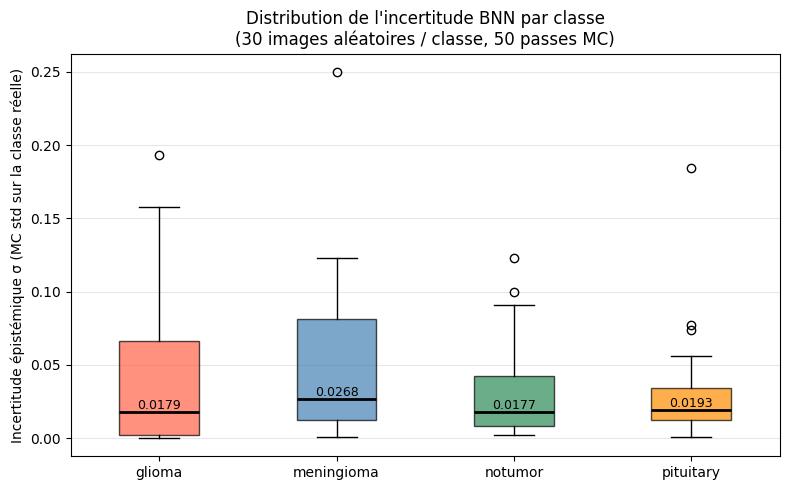

✓ Sauvegardé : uncertainty_per_class.png

σ médian par classe :
  glioma        médiane=0.0179  max=0.1934
  meningioma    médiane=0.0268  max=0.2499
  notumor       médiane=0.0177  max=0.1228
  pituitary     médiane=0.0193  max=0.1843


In [32]:
N_UNCERT = 30
CLIN_MED  = np.array([[0.5]], dtype=np.float32)

sigma_per_class = {cls: [] for cls in CLASSES}

model.eval()
for cls in CLASSES:
    cls_dir  = os.path.join(TEST_DIR, cls)
    paths    = glob.glob(os.path.join(cls_dir, "*.jpg"))
    sampled  = random.sample(paths, min(N_UNCERT, len(paths)))
    true_idx = CLASSES.index(cls)

    for p in sampled:
        img_t       = load_image(p)
        _, std_p    = predict_bnn(img_t, CLIN_MED)
        sigma_per_class[cls].append(std_p[0, true_idx])

fig, ax = plt.subplots(figsize=(8, 5))

data   = [sigma_per_class[cls] for cls in CLASSES]
bp     = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2))

for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(1, NUM_CLASSES + 1))
ax.set_xticklabels(CLASSES)
ax.set_ylabel("Incertitude épistémique σ (MC std sur la classe réelle)")
ax.set_title(f"Distribution de l'incertitude BNN par classe\n"
             f"({N_UNCERT} images aléatoires / classe, {MC_PASSES} passes MC)")
ax.grid(True, alpha=0.3, axis="y")

for i, cls in enumerate(CLASSES):
    med = np.median(sigma_per_class[cls])
    ax.text(i + 1, med + 0.002, f"{med:.4f}", ha="center", fontsize=9, color="black")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/uncertainty_per_class.png", dpi=150)
plt.show()
print("✓ Sauvegardé : uncertainty_per_class.png")

print("\nσ médian par classe :")
for cls in CLASSES:
    vals = sigma_per_class[cls]
    print(f"  {cls:12s}  médiane={np.median(vals):.4f}  max={np.max(vals):.4f}")

### 6. Calibration bayésienne (reliability diagram et ECE)

ECE = 0.0085  (0 = parfaitement calibré, 1 = totalement décalibré)


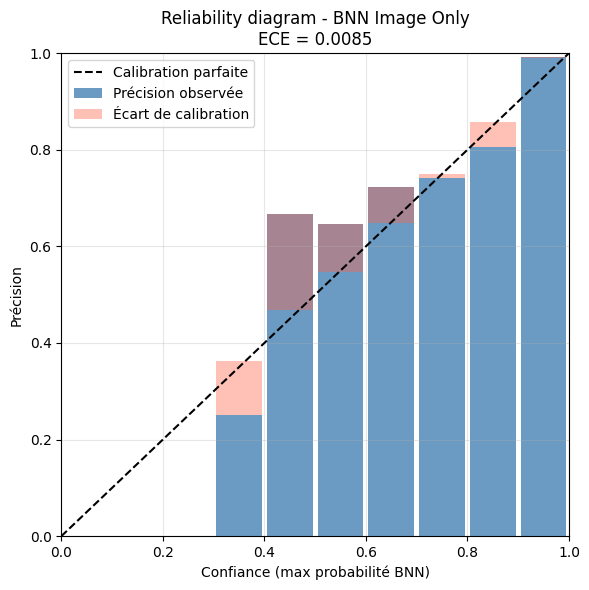

✓ Sauvegardé : calibration.png


In [33]:
import os, glob
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pickle

with open("predicted_clinical.pkl", "rb") as f:
    predicted_clinical = pickle.load(f)

class TumorDatasetCal(Dataset):
    def __init__(self, root, split_clinical, transform, classes):
        self.samples   = []
        self.transform = transform
        for label, cls in enumerate(classes):
            cls_dir = os.path.join(root, cls)
            for ext in ["*.jpg", "*.jpeg", "*.png"]:
                for p in glob.glob(os.path.join(cls_dir, ext)):
                    clin = split_clinical.get(p, np.array([0.5], dtype=np.float32))
                    self.samples.append((p, label, clin))
    def __len__(self):  return len(self.samples)
    def __getitem__(self, idx):
        p, label, clin = self.samples[idx]
        img = Image.open(p).convert("RGB")
        return self.transform(img), torch.tensor(clin, dtype=torch.float32), label

cal_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

cal_dataset = TumorDatasetCal(
    os.path.join(DATAROOT, "Test"),
    predicted_clinical["test"],
    cal_tf, CLASSES
)
cal_loader = DataLoader(cal_dataset, batch_size=32, shuffle=False, num_workers=0)

model.eval()
all_confs, all_corrects = [], []
all_labels, all_preds, all_sigmas = [], [], []

with torch.no_grad():
    for imgs, clins, labels in cal_loader:
        imgs, clins = imgs.to(device), clins.to(device)
        passes = torch.stack([
            torch.softmax(model(imgs, clins), dim=1)
            for _ in range(MC_PASSES)
        ])
        mean_p = passes.mean(dim=0)
        std_p  = passes.std(dim=0)
        confs, preds = mean_p.max(dim=1)
        correct = (preds.cpu() == labels)
        
        all_confs.extend(confs.cpu().numpy())
        all_corrects.extend(correct.numpy())
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_sigmas.extend(std_p.max(dim=1).values.cpu().numpy())

all_confs    = np.array(all_confs)
all_corrects = np.array(all_corrects, dtype=float)
all_labels   = np.array(all_labels)
all_preds    = np.array(all_preds)
all_sigmas   = np.array(all_sigmas)

M = 10
bin_edges   = np.linspace(0, 1, M + 1)
bin_accs    = np.zeros(M)
bin_confs   = np.zeros(M)
bin_counts  = np.zeros(M)

for i in range(M):
    lo, hi = bin_edges[i], bin_edges[i + 1]
    mask   = (all_confs >= lo) & (all_confs < hi)
    if mask.sum() > 0:
        bin_accs[i]   = all_corrects[mask].mean()
        bin_confs[i]  = all_confs[mask].mean()
        bin_counts[i] = mask.sum()

# ECE : pour chaque bin de confiance, on mesure l'écart avec l'accuracy réelle
ECE = np.sum(bin_counts / len(all_confs) * np.abs(bin_accs - bin_confs))
print(f"ECE = {ECE:.4f}  (0 = parfaitement calibré, 1 = totalement décalibré)")

fig, ax = plt.subplots(figsize=(6, 6))

bar_width = 1.0 / M
centers   = bin_edges[:-1] + bar_width / 2

ax.bar(centers, bin_accs, width=bar_width * 0.9,
       color="steelblue", alpha=0.8, label="Précision observée")
ax.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Calibration parfaite")
ax.bar(centers, np.abs(bin_accs - bin_confs), width=bar_width * 0.9,
       bottom=np.minimum(bin_accs, bin_confs),
       color="tomato", alpha=0.4, label="Écart de calibration")

ax.set_xlabel("Confiance (max probabilité BNN)")
ax.set_ylabel("Précision")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(f"Reliability diagram - BNN Image Only\nECE = {ECE:.4f}")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/calibration.png", dpi=150)
plt.show()
print("✓ Sauvegardé : calibration.png")

In [34]:
print("=" * 50)
print("Figures sauvegardées dans", SAVE_DIR)
print("=" * 50)
figures = {
    "uncertainty_per_class.png": "Distribution σ BNN par classe (boxplot)",
    "calibration.png":           "Reliability diagram + ECE",
}
for fname, desc in figures.items():
    path   = os.path.join(SAVE_DIR, fname)
    exists = "✓" if os.path.exists(path) else "✗"
    print(f"  {exists} {fname} — {desc}")

Figures sauvegardées dans runs_analysis
  ✓ uncertainty_per_class.png — Distribution σ BNN par classe (boxplot)
  ✓ calibration.png — Reliability diagram + ECE


### 7. Comparaison avec le CNN baseline

In [35]:
cnn_baseline = models.resnet18(weights="IMAGENET1K_V1")
cnn_baseline.fc = nn.Sequential(
    nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, 4)
)
ckpt_cnn = torch.load("runs_cnn_baseline/best_final.pt", 
                       map_location=device, weights_only=False)
cnn_baseline.load_state_dict(ckpt_cnn["model_state"])
cnn_baseline = cnn_baseline.to(device)
cnn_baseline.eval()

all_confs_cnn, all_corrects_cnn = [], []

with torch.no_grad():
    for imgs, clins, labels in cal_loader:
        imgs = imgs.to(device)
        logits = cnn_baseline(imgs)
        probs = torch.softmax(logits, dim=1)
        confs, preds = probs.max(dim=1)
        correct = (preds.cpu() == labels)
        all_confs_cnn.extend(confs.cpu().numpy())
        all_corrects_cnn.extend(correct.numpy())

all_confs_cnn    = np.array(all_confs_cnn)
all_corrects_cnn = np.array(all_corrects_cnn, dtype=float)

bin_accs_cnn  = np.zeros(M)
bin_confs_cnn = np.zeros(M)
bin_counts_cnn = np.zeros(M)

for i in range(M):
    lo, hi = bin_edges[i], bin_edges[i + 1]
    mask   = (all_confs_cnn >= lo) & (all_confs_cnn < hi)
    if mask.sum() > 0:
        bin_accs_cnn[i]   = all_corrects_cnn[mask].mean()
        bin_confs_cnn[i]  = all_confs_cnn[mask].mean()
        bin_counts_cnn[i] = mask.sum()

ECE_cnn = np.sum(bin_counts_cnn / len(all_confs_cnn) * 
                  np.abs(bin_accs_cnn - bin_confs_cnn))
print(f"ECE CNN baseline = {ECE_cnn:.4f}")
print(f"ECE BNN          = {ECE:.4f}")

ECE CNN baseline = 0.0160
ECE BNN          = 0.0085


### 8. Ratio σ incorrect / σ correct par classe

In [36]:
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

print("Ratio sigma_incorrect / sigma_correct par classe :")
for i, cls in enumerate(classes):
    mask_cls = (all_labels == i)
    
    correct_mask = mask_cls & (all_preds == all_labels)
    incorrect_mask = mask_cls & (all_preds != all_labels)
    
    sigma_correct_cls = all_sigmas[correct_mask].mean()
    sigma_incorrect_cls = all_sigmas[incorrect_mask].mean()
    
    if sigma_incorrect_cls > 0 and len(all_sigmas[incorrect_mask]) > 0:
        ratio = sigma_incorrect_cls / sigma_correct_cls
        print(f"{cls}: {ratio:.2f} ({len(all_sigmas[incorrect_mask])} erreurs)")
    else:
        print(f"{cls}: pas d'erreurs")

Ratio sigma_incorrect / sigma_correct par classe :
glioma: 4.39 (16 erreurs)
meningioma: 3.67 (16 erreurs)
notumor: 8.53 (1 erreurs)
pituitary: 6.23 (8 erreurs)


In [37]:
# ratio global toutes classes confondues
correct_mask_all   = (all_preds == all_labels)
incorrect_mask_all = (all_preds != all_labels)
sig_ok  = all_sigmas[correct_mask_all].mean()
sig_err = all_sigmas[incorrect_mask_all].mean()
ratio_global = sig_err / sig_ok
print(f"σ correct global   : {sig_ok:.4f}")
print(f"σ incorrect global : {sig_err:.4f}")
print(f"Ratio global σ_incorrect / σ_correct : {ratio_global:.2f}")

σ correct global   : 0.0304
σ incorrect global : 0.1467
Ratio global σ_incorrect / σ_correct : 4.83


### 9. Balanced accuracy du CNN baseline

In [38]:
from sklearn.metrics import balanced_accuracy_score

all_preds_cnn, all_labels_cnn = [], []

with torch.no_grad():
    for imgs, clins, labels in cal_loader:
        imgs = imgs.to(device)
        logits = cnn_baseline(imgs)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        all_preds_cnn.extend(preds.cpu().numpy())
        all_labels_cnn.extend(labels.numpy())

bal_acc_cnn = balanced_accuracy_score(all_labels_cnn, all_preds_cnn)
print(f"Balanced accuracy CNN baseline : {bal_acc_cnn:.3f}")

Balanced accuracy CNN baseline : 0.966


### 10. Matrice de confusion

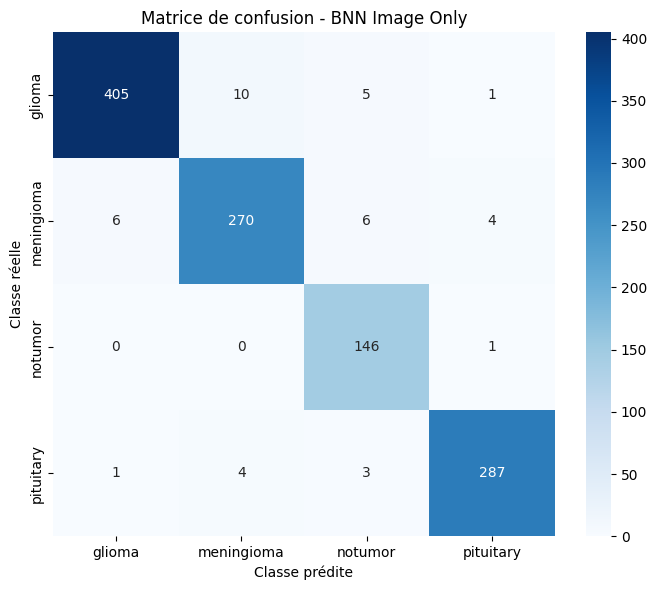

✓ Sauvegardé : confusion_matrix_bnn.png


In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=ax)
ax.set_xlabel('Classe prédite')
ax.set_ylabel('Classe réelle')
ax.set_title('Matrice de confusion - BNN Image Only')
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/confusion_matrix_bnn.png", dpi=150)
plt.show()
print("✓ Sauvegardé : confusion_matrix_bnn.png")

### 11. BNN multimodal, calibration et performances

In [40]:
class BNNMultimodalNet(nn.Module):
    def __init__(self, num_classes=4, clinical_dim=1,
                 cnn_ckpt=None, prior_mu=0, prior_sigma=0.1):
        super().__init__()
        backbone    = models.resnet18(weights="IMAGENET1K_V1")
        backbone.fc = nn.Identity()
        self.cnn    = backbone

        if cnn_ckpt and os.path.exists(cnn_ckpt):
            ckpt     = torch.load(cnn_ckpt, map_location="cpu", weights_only=False)
            state    = ckpt.get("model_state", ckpt)
            filtered = {k: v for k, v in state.items() if not k.startswith("fc.")}
            self.cnn.load_state_dict(filtered, strict=False)

        for name, param in self.cnn.named_parameters():
            param.requires_grad = ("layer4" in name or "layer3" in name)

        self.clinical_mlp = nn.Sequential(
            nn.Linear(clinical_dim, 64), nn.ReLU(),
            nn.Linear(64, 64),           nn.ReLU(),
            nn.Linear(64, 32),           nn.ReLU(),
        )
        self.bnn_head = nn.Sequential(
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=512 + 32, out_features=256),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=256, out_features=128),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=128, out_features=num_classes),
        )

    def forward(self, img, clinical):
        img_feat      = self.cnn(img)
        clinical_feat = self.clinical_mlp(clinical)
        return self.bnn_head(torch.cat([img_feat, clinical_feat], dim=1))


model_ablation = BNNMultimodalNet(clinical_dim=1).to(device)
ckpt_abl = torch.load("runs_bnn_multimodal/best.pt",
                       map_location=device, weights_only=False)
model_ablation.load_state_dict(ckpt_abl["model_state"])
model_ablation.eval()

all_confs_abl, all_corrects_abl = [], []
all_labels_abl, all_preds_abl = [], []

with torch.no_grad():
    for imgs, clins, labels in cal_loader:
        imgs, clins = imgs.to(device), clins.to(device)
        passes = torch.stack([
            torch.softmax(model_ablation(imgs, clins), dim=1)
            for _ in range(MC_PASSES)
        ])
        mean_p = passes.mean(dim=0)
        confs, preds = mean_p.max(dim=1)
        correct = (preds.cpu() == labels)
        all_confs_abl.extend(confs.cpu().numpy())
        all_corrects_abl.extend(correct.numpy())
        all_labels_abl.extend(labels.numpy())
        all_preds_abl.extend(preds.cpu().numpy())

all_confs_abl = np.array(all_confs_abl)
all_corrects_abl = np.array(all_corrects_abl, dtype=float)

bin_counts_abl = np.zeros(M)
bin_accs_abl = np.zeros(M)
bin_confs_abl_arr = np.zeros(M)
for i in range(M):
    lo, hi = bin_edges[i], bin_edges[i+1]
    mask = (all_confs_abl >= lo) & (all_confs_abl < hi)
    if mask.sum() > 0:
        bin_accs_abl[i] = all_corrects_abl[mask].mean()
        bin_confs_abl_arr[i] = all_confs_abl[mask].mean()
        bin_counts_abl[i] = mask.sum()

ECE_abl = np.sum(bin_counts_abl / len(all_confs_abl) * np.abs(bin_accs_abl - bin_confs_abl_arr))
print(f"ECE BNN Multimodal = {ECE_abl:.4f}")

from sklearn.metrics import balanced_accuracy_score
bal_acc_abl = balanced_accuracy_score(all_labels_abl, all_preds_abl)
print(f"Balanced accuracy Multimodal = {bal_acc_abl:.3f}")

ECE BNN Multimodal = 0.0276
Balanced accuracy Multimodal = 0.954


### 12. Rapport de classification complet

In [41]:
from sklearn.metrics import classification_report

print("=== BNN Image Only ===")
print(classification_report(all_labels, all_preds, target_names=CLASSES))

print("=== CNN Baseline ===")
print(classification_report(all_labels_cnn, all_preds_cnn, target_names=CLASSES))

print("=== BNN Multimodal ===")
print(classification_report(all_labels_abl, all_preds_abl, target_names=CLASSES))

=== BNN Image Only ===
              precision    recall  f1-score   support

      glioma       0.98      0.96      0.97       421
  meningioma       0.95      0.94      0.95       286
     notumor       0.91      0.99      0.95       147
   pituitary       0.98      0.97      0.98       295

    accuracy                           0.96      1149
   macro avg       0.96      0.97      0.96      1149
weighted avg       0.97      0.96      0.96      1149

=== CNN Baseline ===
              precision    recall  f1-score   support

      glioma       0.98      0.98      0.98       421
  meningioma       0.96      0.95      0.96       286
     notumor       0.92      0.97      0.94       147
   pituitary       0.99      0.97      0.98       295

    accuracy                           0.97      1149
   macro avg       0.96      0.97      0.96      1149
weighted avg       0.97      0.97      0.97      1149

=== BNN Multimodal ===
              precision    recall  f1-score   support

      gl

### 13. Convergence de l'incertitude selon le nombre de passes MC

5 passes : std moyenne = 0.0317
10 passes : std moyenne = 0.0388
20 passes : std moyenne = 0.0398
30 passes : std moyenne = 0.0392
50 passes : std moyenne = 0.0442
75 passes : std moyenne = 0.0445
100 passes : std moyenne = 0.0441


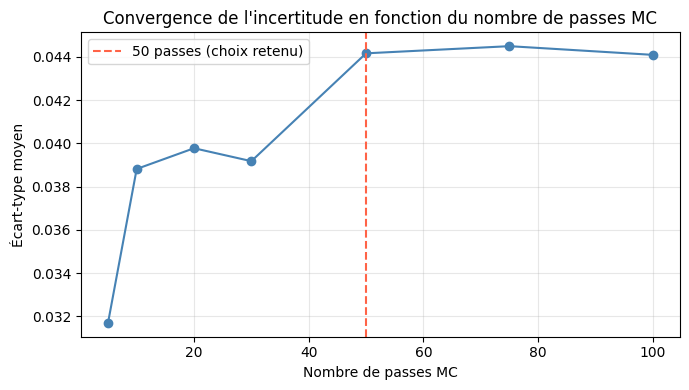

In [42]:
n_passes_list = [5, 10, 20, 30, 50, 75, 100]
mean_stds = []

test_paths = []
for cls in CLASSES:
    cls_dir = os.path.join(TEST_DIR, cls)
    paths = glob.glob(os.path.join(cls_dir, "*.jpg"))
    test_paths.extend(random.sample(paths, 50))

model.eval()
for n in n_passes_list:
    stds = []
    with torch.no_grad():
        for p in test_paths:
            img_t = load_image(p)
            clin_t = torch.tensor([[0.5]], dtype=torch.float32).to(device)
            passes = torch.stack([
                torch.softmax(model(img_t, clin_t), dim=1)
                for _ in range(n)
            ])
            std = passes.std(dim=0).max().item()
            stds.append(std)
    mean_stds.append(np.mean(stds))
    print(f"{n} passes : std moyenne = {np.mean(stds):.4f}")

plt.figure(figsize=(7, 4))
plt.plot(n_passes_list, mean_stds, marker='o', color='steelblue')
plt.xlabel("Nombre de passes MC")
plt.ylabel("Écart-type moyen")
plt.title("Convergence de l'incertitude en fonction du nombre de passes MC")
plt.axvline(x=50, color='tomato', linestyle='--', label='50 passes (choix retenu)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/mc_convergence.png", dpi=150)
plt.show()

### 14. Temps d'inférence comparé

In [51]:
import time

model.eval()
img_test = list(example_images.values())[0]
clin_test = torch.tensor([[0.5]], dtype=torch.float32).to(device)

with torch.no_grad():
    start = time.time()
    for _ in range(100):
        _ = cnn_baseline(img_test)
    cnn_time = (time.time() - start) / 100 * 1000
    print(f"CNN baseline : {cnn_time:.1f} ms par image")

with torch.no_grad():
    start = time.time()
    for _ in range(10):
        passes = torch.stack([
            torch.softmax(model(img_test, clin_test), dim=1)
            for _ in range(50)
        ])
    bnn_time = (time.time() - start) / 10 * 1000
    print(f"BNN image only (50 passes MC) : {bnn_time:.1f} ms par image")

with torch.no_grad():
    start = time.time()
    for _ in range(10):
        passes = torch.stack([
            torch.softmax(model_ablation(img_test, clin_test), dim=1)
            for _ in range(50)
        ])
    abl_time = (time.time() - start) / 10 * 1000
    print(f"BNN Multimodal (50 passes MC) : {abl_time:.1f} ms par image")

CNN baseline : 2.3 ms par image
BNN image only (50 passes MC) : 102.6 ms par image
BNN Multimodal (50 passes MC) : 99.2 ms par image


### 15. Âge cérébral prédit par classe tumorale

In [44]:
import pandas as pd


ages_by_class = {cls: [] for cls in CLASSES}

for imgs, clins, labels in cal_loader:
    for clin, label in zip(clins, labels):
        ages_by_class[CLASSES[label.item()]].append(clin.item() * (86 - 20) + 20)

print("Âge prédit moyen par classe :")
for cls, ages in ages_by_class.items():
    print(f"  {cls:12s}  mean={np.mean(ages):.1f}  std={np.std(ages):.1f}")

Âge prédit moyen par classe :
  glioma        mean=35.0  std=8.2
  meningioma    mean=40.5  std=9.6
  notumor       mean=37.0  std=9.8
  pituitary     mean=35.7  std=8.4


### 16. Ratio σ incorrect / σ correct, visualisation

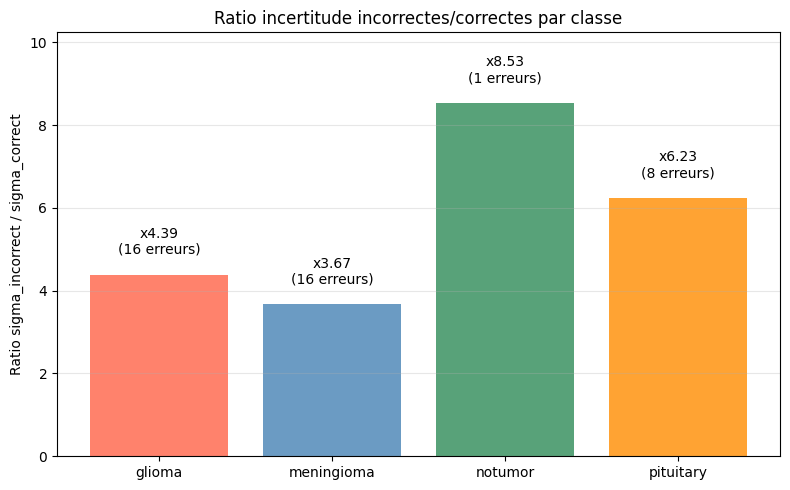

In [45]:
ratios_dyn = []
errors_dyn = []

for i, cls in enumerate(CLASSES):
    mask_cls       = (all_labels == i)
    correct_mask   = mask_cls & (all_preds == all_labels)
    incorrect_mask = mask_cls & (all_preds != all_labels)

    n_err = int(incorrect_mask.sum())
    errors_dyn.append(n_err)

    if n_err > 0:
        sigma_correct   = all_sigmas[correct_mask].mean()
        sigma_incorrect = all_sigmas[incorrect_mask].mean()
        ratios_dyn.append(sigma_incorrect / sigma_correct)
    else:
        ratios_dyn.append(0)

colors = ['tomato', 'steelblue', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(CLASSES, ratios_dyn, color=colors, alpha=0.8)

for bar, ratio, err in zip(bars, ratios_dyn, errors_dyn):
    if ratio > 0:
        label = f'x{ratio:.2f}\n({err} erreurs)'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                label, ha='center', fontsize=10)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, 0.5,
                "(pas d'erreurs)", ha='center', fontsize=10)

ax.set_ylabel('Ratio sigma_incorrect / sigma_correct')
ax.set_title('Ratio incertitude incorrectes/correctes par classe')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(ratios_dyn) * 1.2 if max(ratios_dyn) > 0 else 10)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/ratio_sigma_par_classe.png', dpi=150)
plt.show()

### 17. Accuracy vs Coverage et compromis charge de travail / sécurité

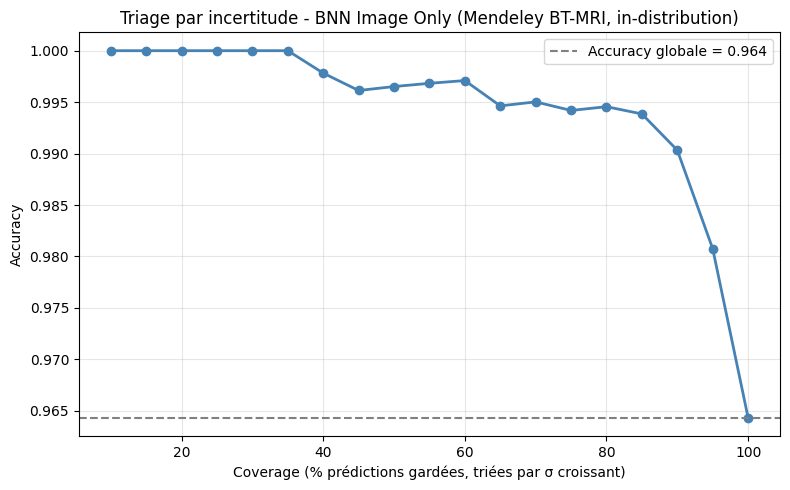

Accuracy top 50% confiantes : 0.997
Accuracy globale            : 0.964

Seuil opérationnel BNN Image Only :
  Renvoyer les 10% les plus incertains : capture 75.6% des erreurs
  Renvoyer les 20% les plus incertains : capture 87.8% des erreurs
  Renvoyer les 30% les plus incertains : capture 90.2% des erreurs
  Renvoyer les 40% les plus incertains : capture 95.1% des erreurs
  Renvoyer les 50% les plus incertains : capture 95.1% des erreurs


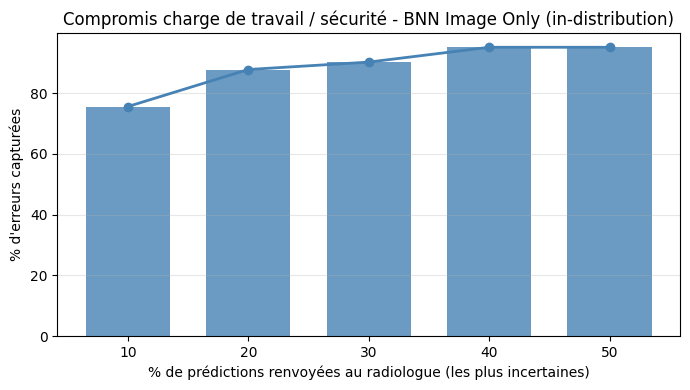

✓ Sauvegardé : accuracy_vs_coverage.png et triage_threshold.png


In [49]:
# ── Figure 1 : Accuracy vs Coverage ──────────────────────────────────────────
order          = np.argsort(all_sigmas)
labels_sorted  = all_labels[order]
preds_sorted   = all_preds[order]
correct_sorted = (preds_sorted == labels_sorted).astype(float)

coverages = np.linspace(0.1, 1.0, 19)
accs = []
for c in coverages:
    k = int(c * len(correct_sorted))
    accs.append(correct_sorted[:k].mean() if k > 0 else np.nan)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(coverages * 100, accs, marker="o", color="steelblue", linewidth=2)
ax.axhline(correct_sorted.mean(), color="gray", linestyle="--",
           label=f"Accuracy globale = {correct_sorted.mean():.3f}")
ax.set_xlabel("Coverage (% prédictions gardées, triées par σ croissant)")
ax.set_ylabel("Accuracy")
ax.set_title("Triage par incertitude - BNN Image Only (Mendeley BT-MRI, in-distribution)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/accuracy_vs_coverage.png", dpi=150)
plt.show()
print(f"Accuracy top 50% confiantes : {correct_sorted[:len(correct_sorted)//2].mean():.3f}")
print(f"Accuracy globale            : {correct_sorted.mean():.3f}")

# ── Figure 2 : Compromis charge de travail / sécurité ────────────────────────
errors_sorted  = (correct_sorted == 0).astype(float)
n_errors_total = errors_sorted.sum()
n_tot          = len(correct_sorted)

print("\nSeuil opérationnel BNN Image Only :")
for coverage in [0.1, 0.2, 0.3, 0.4, 0.5]:
    k = int(coverage * n_tot)
    errors_captured = errors_sorted[n_tot - k:].sum()
    pct_errors = errors_captured / n_errors_total * 100
    print(f"  Renvoyer les {int(coverage*100)}% les plus incertains : "
          f"capture {pct_errors:.1f}% des erreurs")

coverages_pct       = [10, 20, 30, 40, 50]
errors_captured_pct = []
for coverage in [0.1, 0.2, 0.3, 0.4, 0.5]:
    k = int(coverage * n_tot)
    errors_captured = errors_sorted[n_tot - k:].sum()
    errors_captured_pct.append(errors_captured / n_errors_total * 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(coverages_pct, errors_captured_pct, color="steelblue", alpha=0.8, width=7)
ax.plot(coverages_pct, errors_captured_pct, marker="o", color="steelblue", linewidth=2)
ax.set_xlabel("% de prédictions renvoyées au radiologue (les plus incertaines)")
ax.set_ylabel("% d'erreurs capturées")
ax.set_title("Compromis charge de travail / sécurité - BNN Image Only (in-distribution)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/triage_threshold.png", dpi=150)
plt.show()
print("✓ Sauvegardé : accuracy_vs_coverage.png et triage_threshold.png")